# 03 — Explainabilité SHAP
## XGBoost — Diabetes Prediction

**SHAP (SHapley Additive exPlanations)** est une méthode mathématique qui explique
les prédictions d'un modèle ML en calculant la contribution de chaque feature.

**Principe :** Pour chaque prédiction, SHAP répond à :
*Pourquoi le modèle a-t-il prédit diabétique pour CE patient ?*
*Quelle feature a le plus influencé cette décision ?*

**Ce qu'on analyse ici :**
1. Feature Importance globale — quelles variables comptent le plus sur TOUT le dataset
2. Summary Plot — comment chaque variable influence les prédictions
3. Dependence Plot — relation entre la valeur d'une variable et son impact
4. Waterfall Plot — explication détaillée pour UN patient
5. Force Plot — visualisation de la décision pour un patient
6. Analyse des Faux Négatifs — pourquoi le modèle rate certains diabétiques
7. Heatmap — vue globale sur un échantillon de patients

## 1. Imports & Chargement

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
shap.initjs()

print('SHAP version :', shap.__version__)

SHAP version : 0.51.0


## 2. Chargement des données et du modèle XGBoost

In [2]:
from src.preprocessing import load_data, prepare_data
from src.preprocessing import NUMERIC_FEATURES, BINARY_FEATURES, CATEGORICAL_FEATURES

# Charger les donnees
df = load_data('../data/diabetes_prediction_dataset.csv')
X_train, X_val, X_test, y_train, y_val, y_test, preprocessor = prepare_data(df)

# Charger le modele XGBoost sauvegarde
with open('../models/best_model.pkl', 'rb') as f:
    model = pickle.load(f)

print(f'Modele charge  : {type(model).__name__}')
print(f'X_test shape   : {X_test.shape}')
print(f'Diabetiques    : {y_test.sum()} ({y_test.mean()*100:.1f}%)')
print(f'Non-diabetiques: {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)')

Dataset chargé : 100000 lignes, 9 colonnes
Diabétiques    : 8500 (8.5%)
Non-diabét.    : 91500 (91.5%)

Train      : 68000 exemples | Diabétiques: 5780 (8.5%)
Validation : 12000 exemples   | Diabétiques: 1020 (8.5%)
Test       : 20000 exemples  | Diabétiques: 1700 (8.5%)
Total      : 100000
Modele charge  : XGBClassifier
X_test shape   : (20000, 15)
Diabetiques    : 1700 (8.5%)
Non-diabetiques: 18300 (91.5%)


## 3. Récupération des noms de features

Après le `ColumnTransformer`, les colonnes catégorielles sont encodées en OneHot.
Par exemple `gender` devient `gender_Female`, `gender_Male`, `gender_Other`.
On récupère tous les noms dans l'ordre exact du preprocessing.

In [3]:
# Recuperer les noms apres OneHotEncoder
cat_encoder   = preprocessor.named_transformers_['cat']
cat_names     = cat_encoder.get_feature_names_out(CATEGORICAL_FEATURES).tolist()

# Ordre : numeriques + binaires + categorielle encodees
feature_names = NUMERIC_FEATURES + BINARY_FEATURES + cat_names

print(f'Nombre total de features apres preprocessing : {len(feature_names)}')
print(f'\nListe complete :')
for i, f in enumerate(feature_names):
    print(f'  {i:>2}. {f}')

Nombre total de features apres preprocessing : 15

Liste complete :
   0. age
   1. bmi
   2. HbA1c_level
   3. blood_glucose_level
   4. hypertension
   5. heart_disease
   6. gender_Female
   7. gender_Male
   8. gender_Other
   9. smoking_history_No Info
  10. smoking_history_current
  11. smoking_history_ever
  12. smoking_history_former
  13. smoking_history_never
  14. smoking_history_not current


## 4. Calcul des valeurs SHAP

**TreeExplainer** est l'explainer optimisé pour les modèles à base d'arbres (XGBoost, RandomForest).
Il calcule les valeurs SHAP exactes très rapidement.

**Interprétation des valeurs SHAP :**
- Valeur SHAP **positive** → cette feature pousse vers la prédiction **Diabétique**
- Valeur SHAP **négative** → cette feature pousse vers la prédiction **Non-Diabétique**
- Valeur SHAP **proche de 0** → cette feature n'a pas d'impact sur cette prédiction

**Base value** = probabilité moyenne de diabète dans le dataset (point de départ)

In [4]:
# Creer l'explainer SHAP pour XGBoost
explainer = shap.TreeExplainer(model)

# Calculer les valeurs SHAP sur le test set complet
shap_values = explainer.shap_values(X_test)

print(f'Shape shap_values  : {shap_values.shape}')
print(f'  -> {shap_values.shape[0]} patients')
print(f'  -> {shap_values.shape[1]} features')
print(f'\nBase value (expected_value) : {explainer.expected_value:.4f}')
print(f'  -> Probabilite moyenne de diabete : {explainer.expected_value:.1%}')
print(f'\nExemple pour le premier patient :')
print(f'  Base value                : {explainer.expected_value:.4f}')
print(f'  Somme des SHAP values     : {shap_values[0].sum():.4f}')
print(f'  Proba predite (approx)    : {explainer.expected_value + shap_values[0].sum():.4f}')
print(f'  Proba predite (modele)    : {model.predict_proba(X_test)[0, 1]:.4f}')

Shape shap_values  : (20000, 15)
  -> 20000 patients
  -> 15 features

Base value (expected_value) : -0.1136
  -> Probabilite moyenne de diabete : -11.4%

Exemple pour le premier patient :
  Base value                : -0.1136
  Somme des SHAP values     : -3.3882
  Proba predite (approx)    : -3.5018
  Proba predite (modele)    : 0.0293


## 5. Feature Importance Globale

L'importance globale d'une feature = **moyenne de |valeur SHAP|** sur tous les patients.

**Différence avec l'importance classique de XGBoost :**
- XGBoost natif : compte combien de fois une feature est utilisée dans les arbres
- SHAP : mesure l'impact réel sur la prédiction finale — plus fiable et interprétable

Feature Importance Globale (SHAP) :


,Feature,Importance SHAP
0,HbA1c_level,3.740493
1,blood_glucose_level,2.735821
2,age,1.072232
3,bmi,0.484756
4,smoking_history_No Info,0.129457
5,gender_Male,0.127989
6,hypertension,0.118634
7,heart_disease,0.069644
8,smoking_history_never,0.057969
9,gender_Female,0.052048


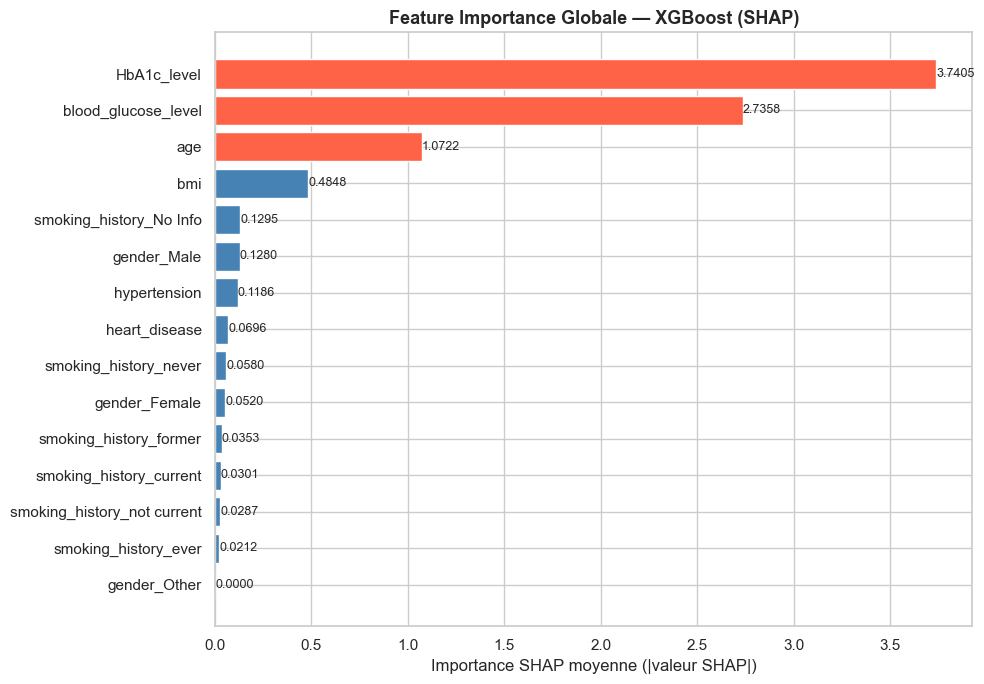

Top 3 features les plus importantes :
  1. HbA1c_level                         : 3.7405
  2. blood_glucose_level                 : 2.7358
  3. age                                 : 1.0722


In [5]:
# Calcul importance globale
mean_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance SHAP': mean_shap
}).sort_values('Importance SHAP', ascending=False).reset_index(drop=True)

print('Feature Importance Globale (SHAP) :')
display(importance_df)

# Graphique
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['tomato' if i < 3 else 'steelblue' for i in range(len(importance_df))]
ax.barh(
    importance_df['Feature'][::-1],
    importance_df['Importance SHAP'][::-1],
    color=colors[::-1], edgecolor='white'
)
ax.set_xlabel('Importance SHAP moyenne (|valeur SHAP|)')
ax.set_title('Feature Importance Globale — XGBoost (SHAP)',
             fontsize=13, fontweight='bold')
for i, v in enumerate(importance_df['Importance SHAP'][::-1]):
    ax.text(v + 0.0005, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f'Top 3 features les plus importantes :')
for i in range(3):
    print(f'  {i+1}. {importance_df["Feature"][i]:<35} : {importance_df["Importance SHAP"][i]:.4f}')

## 6. Summary Plot — Distribution de l'impact SHAP

C'est le graphique **le plus informatif** de SHAP.

**Lecture :**
- Chaque point = un patient
- **Position horizontale** = valeur SHAP (impact sur la prédiction)
- **Couleur rouge** = valeur élevée de la feature pour ce patient
- **Couleur bleue** = valeur faible de la feature pour ce patient

**Exemple d'interprétation :**
Si `blood_glucose_level` a des points rouges à droite → les patients avec
une glycémie élevée ont une valeur SHAP positive → le modèle les prédit diabétiques.

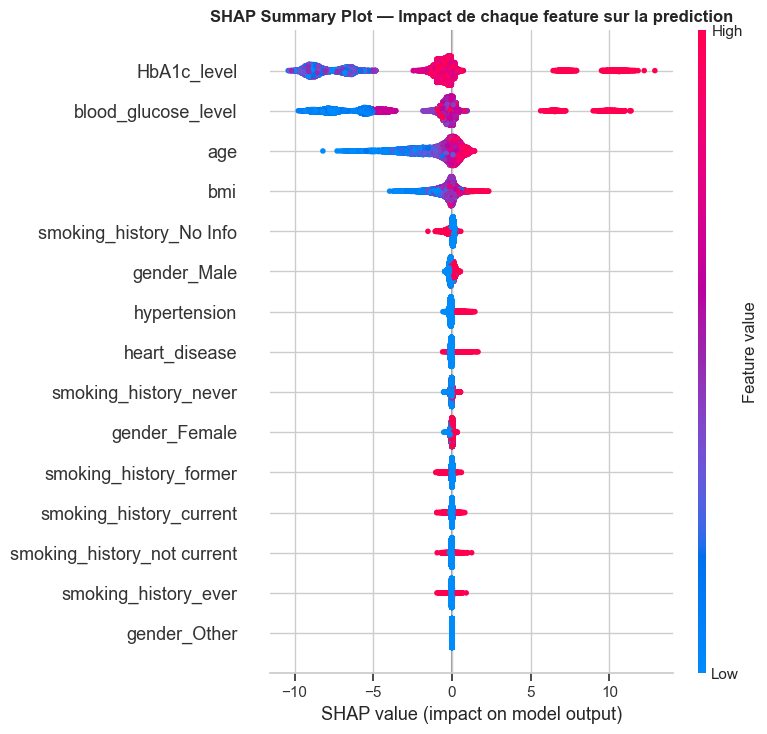

In [6]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP Summary Plot — Impact de chaque feature sur la prediction',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Summary Plot (Bar) — Vue simplifiée

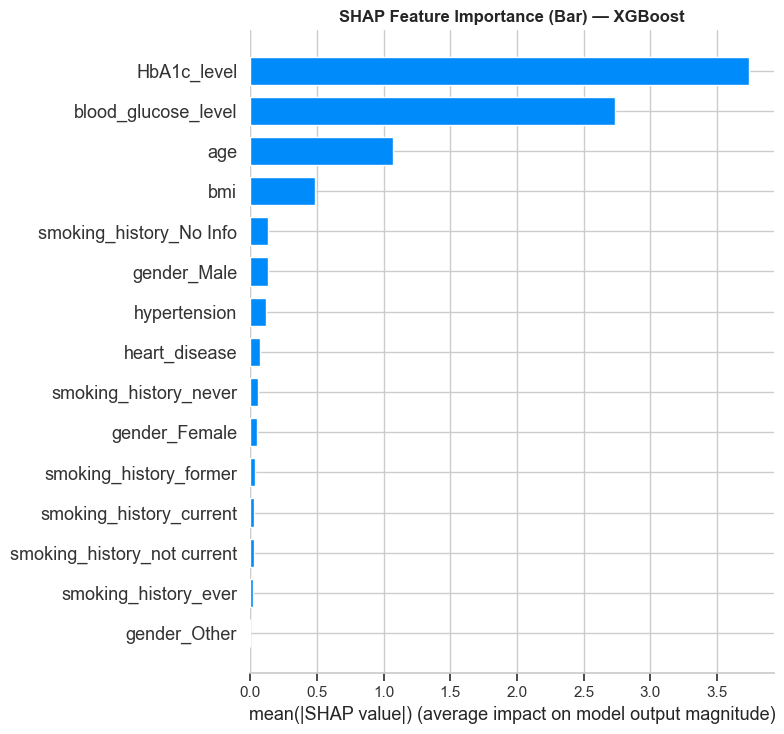

In [7]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=feature_names,
    plot_type='bar',
    show=False
)
plt.title('SHAP Feature Importance (Bar) — XGBoost',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Dependence Plots — Relation valeur / impact SHAP

Le Dependence Plot montre **comment la valeur d'une feature influence son impact SHAP**.

**Lecture :**
- Axe X = valeur de la feature pour chaque patient
- Axe Y = valeur SHAP de cette feature (impact sur la prédiction)
- Couleur = une 2ème feature corrélée détectée automatiquement

Si la courbe monte de gauche à droite → plus la valeur est élevée, plus elle pousse vers diabétique.

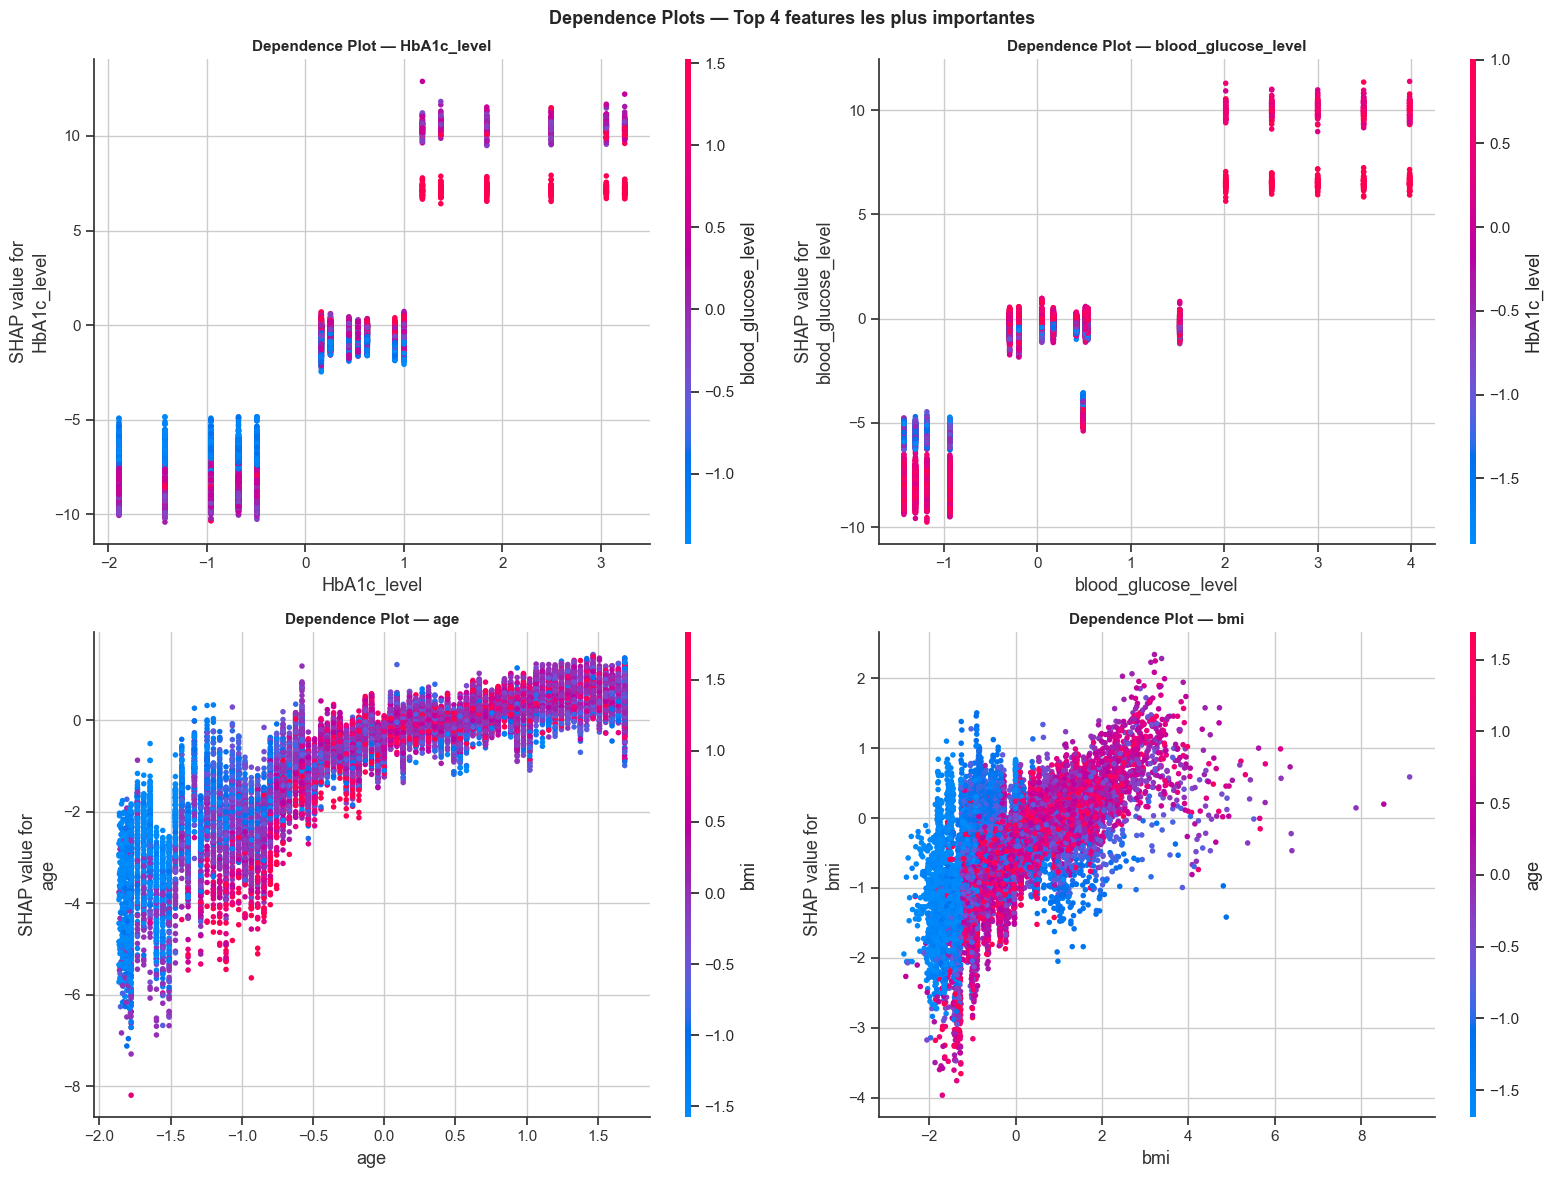

In [8]:
top_features = importance_df['Feature'].head(4).tolist()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    feat_idx = feature_names.index(feat)
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_test,
        feature_names=feature_names,
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f'Dependence Plot — {feat}',
                      fontsize=11, fontweight='bold')

plt.suptitle('Dependence Plots — Top 4 features les plus importantes',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Identification des cas pour l'analyse individuelle

On identifie :
- **TP (Vrai Positif)** : diabétique correctement détecté
- **FN (Faux Négatif)** : diabétique manqué — le plus critique
- **TN (Vrai Négatif)** : non-diabétique correctement identifié
- **FP (Faux Positif)** : non-diabétique prédit comme diabétique

In [9]:
THRESHOLD = 0.1  # Seuil retenu pour XGBoost

y_proba_test = model.predict_proba(X_test)[:, 1]
y_pred_test  = (y_proba_test >= THRESHOLD).astype(int)

tp_indices = np.where((y_test.values == 1) & (y_pred_test == 1))[0]
fn_indices = np.where((y_test.values == 1) & (y_pred_test == 0))[0]
tn_indices = np.where((y_test.values == 0) & (y_pred_test == 0))[0]
fp_indices = np.where((y_test.values == 0) & (y_pred_test == 1))[0]

print(f'Seuil de decision : {THRESHOLD}')
print(f'TP (diabetiques detectes)  : {len(tp_indices)}')
print(f'FN (diabetiques manques)   : {len(fn_indices)} <- CRITIQUE')
print(f'TN (non-diabetiques OK)    : {len(tn_indices)}')
print(f'FP (fausses alertes)       : {len(fp_indices)}')
print(f'\nRecall      : {len(tp_indices)/(len(tp_indices)+len(fn_indices)):.4f}')
print(f'Specificite : {len(tn_indices)/(len(tn_indices)+len(fp_indices)):.4f}')

Seuil de decision : 0.1
TP (diabetiques detectes)  : 1654
FN (diabetiques manques)   : 46 <- CRITIQUE
TN (non-diabetiques OK)    : 14605
FP (fausses alertes)       : 3695

Recall      : 0.9729
Specificite : 0.7981


## 10. Waterfall Plot — Explication individuelle

Le Waterfall Plot explique la prédiction pour **un seul patient**.

**Lecture :**
- **E[f(x)]** = base value (probabilité moyenne = point de départ)
- **f(x)** = probabilité finale prédite pour ce patient
- **Barres rouges** = features qui poussent vers Diabétique (+)
- **Barres bleues** = features qui poussent vers Non-Diabétique (-)
- La somme de toutes les barres = f(x) - E[f(x)]

PATIENT TP (Diabetique detecte) — index 7
  Probabilite predite : 0.9997
  Prediction          : Diabetique
  Realite             : Diabetique

Valeurs du patient :


,age,bmi,HbA1c_level,blood_glucose_level,hypertension,heart_disease,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,0.534,-1.327,0.534,3.491,-0.284,-0.204,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


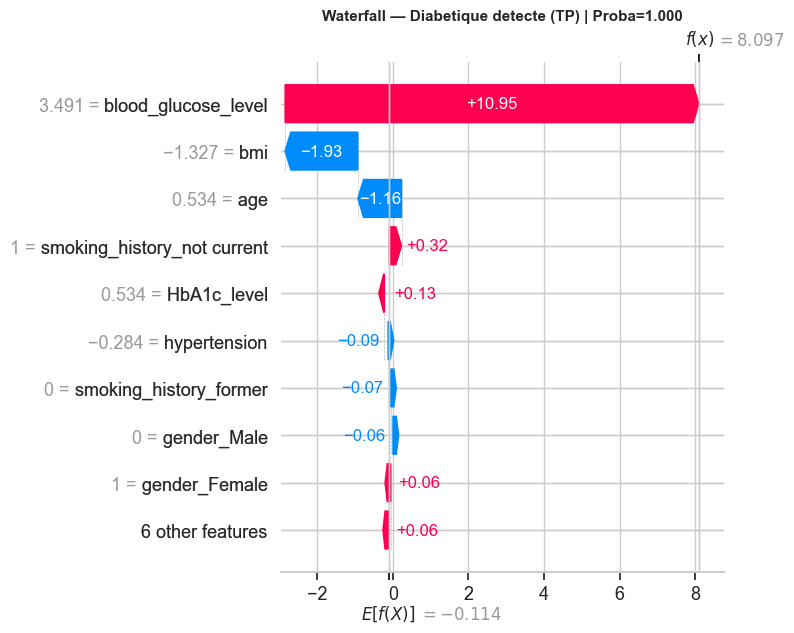

In [10]:
# ── Vrai Positif (diabetique detecte) ──
idx_tp = tp_indices[0]
print(f'PATIENT TP (Diabetique detecte) — index {idx_tp}')
print(f'  Probabilite predite : {y_proba_test[idx_tp]:.4f}')
print(f'  Prediction          : Diabetique')
print(f'  Realite             : Diabetique')

# Valeurs du patient
patient_tp = pd.DataFrame([X_test[idx_tp]], columns=feature_names)
print(f'\nValeurs du patient :')
display(patient_tp.round(3))

shap_exp_tp = shap.Explanation(
    values        = shap_values[idx_tp],
    base_values   = explainer.expected_value,
    data          = X_test[idx_tp],
    feature_names = feature_names
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp_tp, show=False)
plt.title(
    f'Waterfall — Diabetique detecte (TP) | Proba={y_proba_test[idx_tp]:.3f}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

## 11. Waterfall Plot — Faux Négatif (diabétique manqué)

C'est le cas le plus critique — le modèle a raté un diabétique.
On analyse **pourquoi** pour comprendre les limites du modèle.

PATIENT FN (Diabetique MANQUE) — index 1065
  Probabilite predite : 0.0566
  Prediction          : Non-diabetique (ERREUR)
  Realite             : Diabetique

Valeurs du patient :


,age,bmi,HbA1c_level,blood_glucose_level,hypertension,heart_disease,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,-0.311,4.534,0.628,0.416,-0.284,-0.204,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


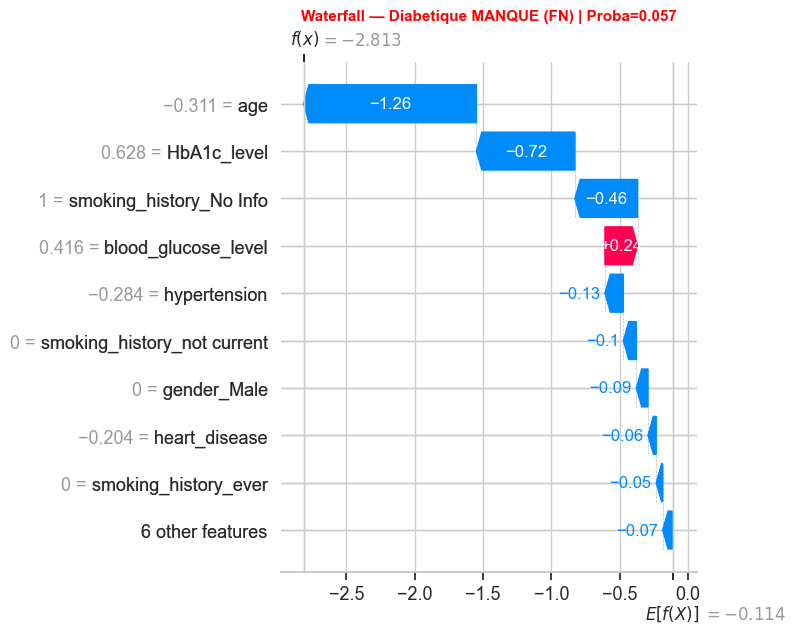


Features qui ont pousse vers NON-diabetique (SHAP negatif) :


,Feature,SHAP
0,age,-1.2649
2,HbA1c_level,-0.7202
9,smoking_history_No Info,-0.4580
4,hypertension,-0.1347
14,smoking_history_not current,-0.0951


In [11]:
if len(fn_indices) > 0:
    idx_fn = fn_indices[0]
    print(f'PATIENT FN (Diabetique MANQUE) — index {idx_fn}')
    print(f'  Probabilite predite : {y_proba_test[idx_fn]:.4f}')
    print(f'  Prediction          : Non-diabetique (ERREUR)')
    print(f'  Realite             : Diabetique')

    patient_fn = pd.DataFrame([X_test[idx_fn]], columns=feature_names)
    print(f'\nValeurs du patient :')
    display(patient_fn.round(3))

    shap_exp_fn = shap.Explanation(
        values        = shap_values[idx_fn],
        base_values   = explainer.expected_value,
        data          = X_test[idx_fn],
        feature_names = feature_names
    )

    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap_exp_fn, show=False)
    plt.title(
        f'Waterfall — Diabetique MANQUE (FN) | Proba={y_proba_test[idx_fn]:.3f}',
        fontsize=11, fontweight='bold', color='red'
    )
    plt.tight_layout()
    plt.show()

    # Quelles features ont pousse vers non-diabetique
    print('\nFeatures qui ont pousse vers NON-diabetique (SHAP negatif) :')
    shap_fn_df = pd.DataFrame({
        'Feature': feature_names,
        'SHAP':    shap_values[idx_fn]
    }).sort_values('SHAP')
    display(shap_fn_df[shap_fn_df['SHAP'] < 0].head(5).round(4))
else:
    print('Aucun FN avec ce seuil — Recall parfait !')

## 12. Waterfall Plot — Vrai Négatif (non-diabétique correct)

PATIENT TN (Non-diabetique correct) — index 0
  Probabilite predite : 0.0293
  Prediction          : Non-diabetique
  Realite             : Non-diabetique

Valeurs du patient :


,age,bmi,HbA1c_level,blood_glucose_level,hypertension,heart_disease,gender_Female,gender_Male,gender_Other,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,-0.266,-0.708,0.441,0.539,-0.284,-0.204,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


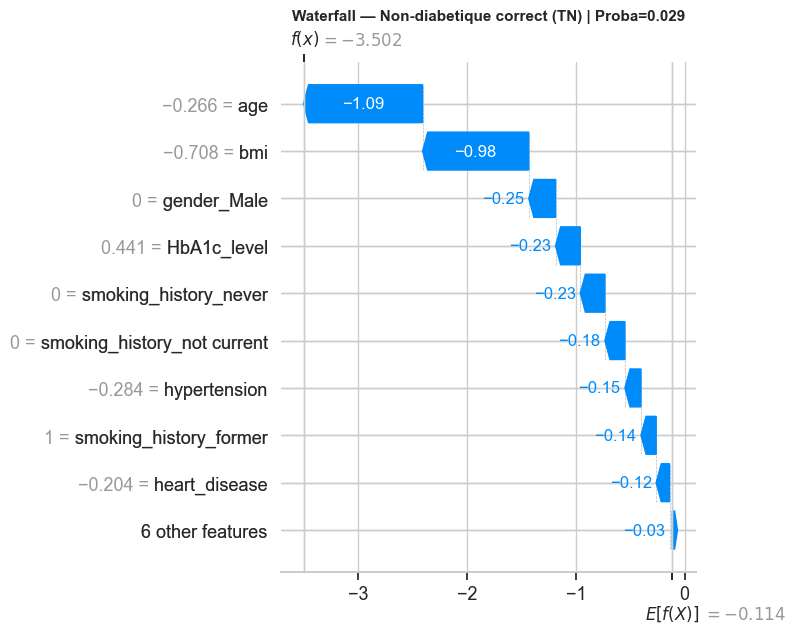

In [12]:
idx_tn = tn_indices[0]
print(f'PATIENT TN (Non-diabetique correct) — index {idx_tn}')
print(f'  Probabilite predite : {y_proba_test[idx_tn]:.4f}')
print(f'  Prediction          : Non-diabetique')
print(f'  Realite             : Non-diabetique')

patient_tn = pd.DataFrame([X_test[idx_tn]], columns=feature_names)
print(f'\nValeurs du patient :')
display(patient_tn.round(3))

shap_exp_tn = shap.Explanation(
    values        = shap_values[idx_tn],
    base_values   = explainer.expected_value,
    data          = X_test[idx_tn],
    feature_names = feature_names
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp_tn, show=False)
plt.title(
    f'Waterfall — Non-diabetique correct (TN) | Proba={y_proba_test[idx_tn]:.3f}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.show()

## 13. Force Plot — Vue horizontale

Le Force Plot montre la même information que le Waterfall mais de façon horizontale.
- **Rouge** = features qui poussent vers Diabétique
- **Bleu** = features qui poussent vers Non-Diabétique
- La largeur de chaque bande = l'importance de la feature

Force Plot — Diabetique detecte (TP) :


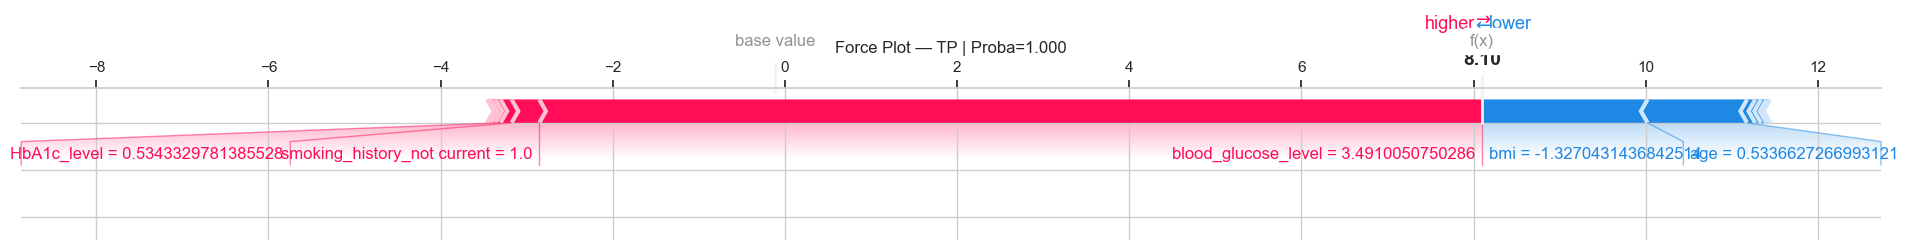


Force Plot — Non-diabetique correct (TN) :


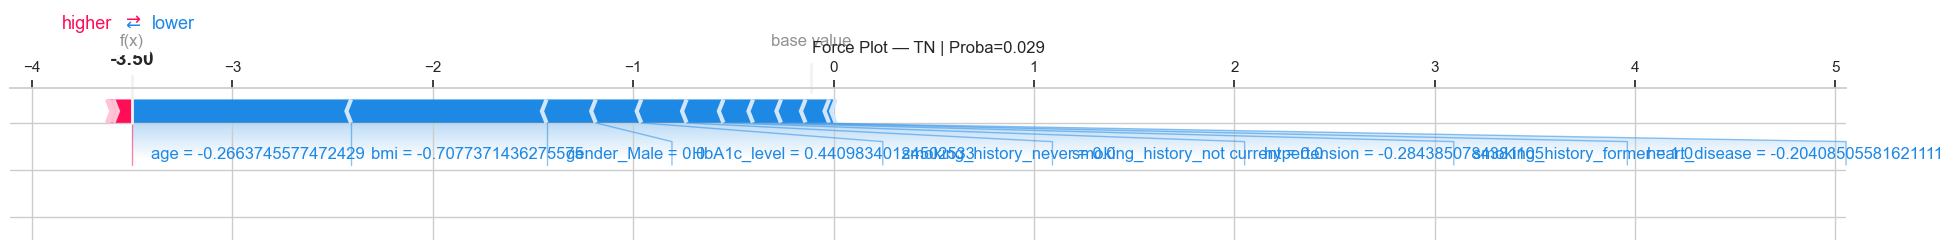

In [13]:
print('Force Plot — Diabetique detecte (TP) :')
shap.force_plot(
    explainer.expected_value,
    shap_values[idx_tp],
    X_test[idx_tp],
    feature_names=feature_names,
    matplotlib=True,
    show=False
)
plt.title(f'Force Plot — TP | Proba={y_proba_test[idx_tp]:.3f}')
plt.tight_layout()
plt.show()

print('\nForce Plot — Non-diabetique correct (TN) :')
shap.force_plot(
    explainer.expected_value,
    shap_values[idx_tn],
    X_test[idx_tn],
    feature_names=feature_names,
    matplotlib=True,
    show=False
)
plt.title(f'Force Plot — TN | Proba={y_proba_test[idx_tn]:.3f}')
plt.tight_layout()
plt.show()

## 14. Heatmap SHAP — Vue globale

La heatmap montre les valeurs SHAP pour un échantillon de patients.
- Chaque **ligne** = un patient
- Chaque **colonne** = une feature
- **Rouge** = valeur SHAP positive (pousse vers diabétique)
- **Bleu** = valeur SHAP négative (pousse vers non-diabétique)

Permet de détecter des patterns : certains patients ont des profils similaires.

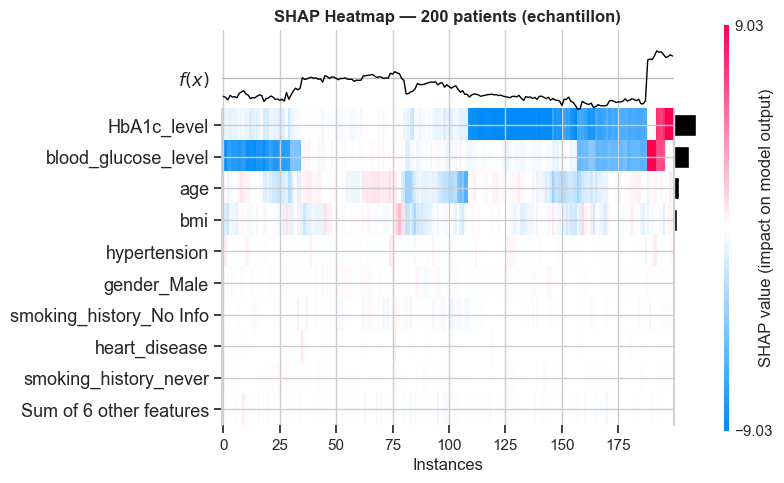

In [14]:
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=200, replace=False)

shap_sample = shap.Explanation(
    values        = shap_values[sample_idx],
    base_values   = np.full(len(sample_idx), explainer.expected_value),
    data          = X_test[sample_idx],
    feature_names = feature_names
)

plt.figure(figsize=(14, 8))
shap.plots.heatmap(shap_sample, show=False)
plt.title('SHAP Heatmap — 200 patients (echantillon)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 15. Sauvegarde de l'explainer SHAP

In [15]:
import os
os.makedirs('../models', exist_ok=True)

with open('../models/shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)

print('Fichiers dans models/ :')
for f in os.listdir('../models'):
    size = os.path.getsize(f'../models/{f}') / 1024
    print(f'  {f:<30} {size:.1f} KB')

Fichiers dans models/ :
  best_model.pkl                 261.8 KB
  preprocessor.pkl               2.0 KB
  shap_explainer.pkl             1007.6 KB


## 16. Conclusions SHAP

In [16]:
print('=' * 60)
print('CONCLUSIONS SHAP — XGBoost Diabetes Prediction')
print('=' * 60)

print(f'\n1. Top 5 features les plus importantes :')
for i in range(min(5, len(importance_df))):
    print(f'   {i+1}. {importance_df["Feature"][i]:<35} SHAP={importance_df["Importance SHAP"][i]:.4f}')

print(f'\n2. Logique medicale :')
print(f'   -> blood_glucose_level et HbA1c = marqueurs cliniques du diabete')
print(f'   -> Le modele a appris les bons patterns medicaux')
print(f'   -> Age et BMI confirment les facteurs de risque connus')

print(f'\n3. Interpretabilite individuelle :')
print(f'   -> Pour chaque patient on explique POURQUOI il est predit diabetique')
print(f'   -> Les FN ont des valeurs glucose/HbA1c moins elevees que les TP')

print(f'\n4. Fichiers sauvegardes :')
print(f'   -> models/best_model.pkl      (XGBoost)')
print(f'   -> models/shap_explainer.pkl  (TreeExplainer)')
print(f'   -> models/preprocessor.pkl    (ColumnTransformer)')

print('\n' + '=' * 60)
print('Prochaine etape : FastAPI (api/main.py)')
print('=' * 60)

CONCLUSIONS SHAP — XGBoost Diabetes Prediction

1. Top 5 features les plus importantes :
   1. HbA1c_level                         SHAP=3.7405
   2. blood_glucose_level                 SHAP=2.7358
   3. age                                 SHAP=1.0722
   4. bmi                                 SHAP=0.4848
   5. smoking_history_No Info             SHAP=0.1295

2. Logique medicale :
   -> blood_glucose_level et HbA1c = marqueurs cliniques du diabete
   -> Le modele a appris les bons patterns medicaux
   -> Age et BMI confirment les facteurs de risque connus

3. Interpretabilite individuelle :
   -> Pour chaque patient on explique POURQUOI il est predit diabetique
   -> Les FN ont des valeurs glucose/HbA1c moins elevees que les TP

4. Fichiers sauvegardes :
   -> models/best_model.pkl      (XGBoost)
   -> models/shap_explainer.pkl  (TreeExplainer)
   -> models/preprocessor.pkl    (ColumnTransformer)

Prochaine etape : FastAPI (api/main.py)
